<a href="https://colab.research.google.com/github/isil-ada/cifar10-multi-CNN-benchmark/blob/main/notebook_01_model1_lenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YZM304 Derin Öğrenme – Proje 2
## Model 1: LeNet-5 Benzeri Custom CNN — CIFAR-10
**Veri Seti:** CIFAR-10 (50.000 eğitim, 10.000 test, 10 sınıf, 32×32 RGB)  
**Amaç:** Temel evrişimli katmanlar, aktivasyon, havuzlama ve tam bağlantılı katmanlardan oluşan sade CNN.  
> Google Colab: Runtime → Change runtime type → **T4 GPU**

In [1]:
# ── Kütüphaneler ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {DEVICE}')

Kullanılan cihaz: cuda


In [2]:
# ── Hiperparametreler ─────────────────────────────────────────────────────────
# BATCH_SIZE=128 : bellek/gradyan kararlılığı dengesi
# LR=0.001       : Adam optimizer standart başlangıç değeri
# EPOCHS=30      : overfit olmadan yeterli öğrenme süresi
BATCH_SIZE    = 128
LEARNING_RATE = 0.001
EPOCHS        = 30
NUM_CLASSES   = 10
CLASSES = ('plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck')

In [3]:
# ── Veri Ön İşleme & Yükleme ──────────────────────────────────────────────────
MEAN = [0.4914, 0.4822, 0.4465]   # CIFAR-10 kanal ortalamaları (literatür)
STD  = [0.2023, 0.1994, 0.2010]   # CIFAR-10 kanal std (literatür)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Veri artırma
    transforms.RandomCrop(32, padding=4),     # Veri artırma
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_set = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Eğitim: {len(train_set)} örnek | Test: {len(test_set)} örnek')
print(f'Eğitim batch: {len(train_loader)} | Test batch: {len(test_loader)}')

100%|██████████| 170M/170M [00:04<00:00, 39.2MB/s]


Eğitim: 50000 örnek | Test: 10000 örnek
Eğitim batch: 391 | Test batch: 79


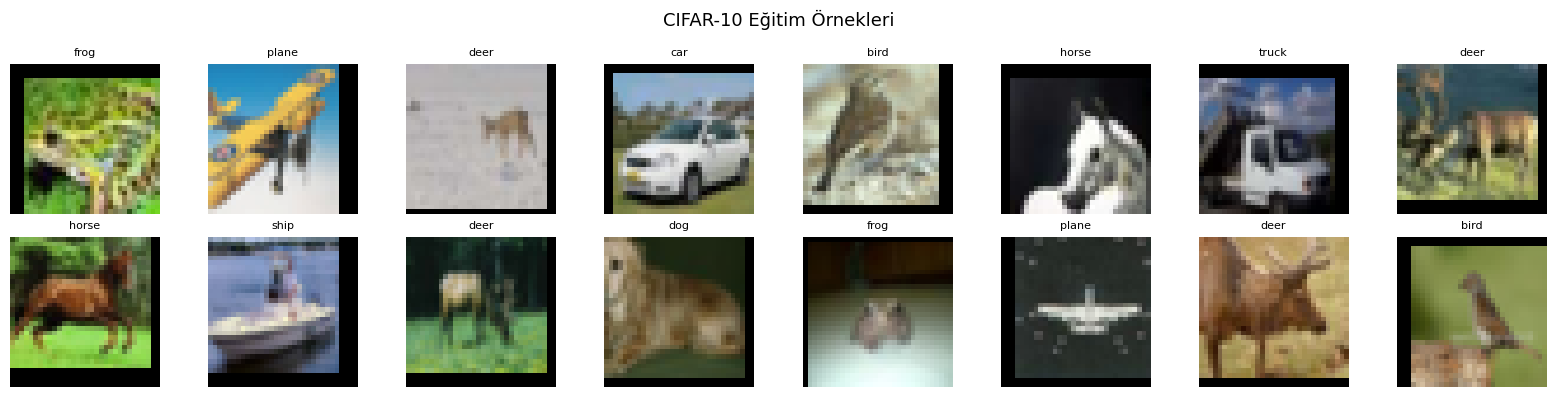

In [4]:
# ── Örnek Görüntüler ──────────────────────────────────────────────────────────
def imshow(img_tensor, title=''):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    img  = (img_tensor * std + mean).clamp(0,1).permute(1,2,0).numpy()
    plt.imshow(img); plt.title(title, fontsize=8); plt.axis('off')

imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16,4))
for i, ax in enumerate(axes.flat):
    plt.sca(ax); imshow(imgs[i], CLASSES[lbls[i]])
plt.suptitle('CIFAR-10 Eğitim Örnekleri', fontsize=13)
plt.tight_layout(); plt.savefig('cifar10_samples.png', dpi=150); plt.show()

In [5]:
# ── Model 1: LeNet-5 Benzeri CNN ──────────────────────────────────────────────
# Mimari:
#   Conv(3→32, 5×5) → ReLU → MaxPool(2×2)   [32→28→14]
#   Conv(32→64, 5×5) → ReLU → MaxPool(2×2)  [14→10→5]
#   Flatten → FC(1600→512) → ReLU → FC(512→10)
#
# LeNet-5'ten farklar: 3 kanallı RGB giriş,
#   genişletilmiş filtre sayısı (32/64), Sigmoid→ReLU

class LeNet5CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=5),   # 32→28
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 28→14
            nn.Conv2d(32, 64, kernel_size=5),   # 14→10
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                  # 10→5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model1 = LeNet5CIFAR(NUM_CLASSES).to(DEVICE)
print(model1)
print(f'\nToplam eğitilebilir parametre: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}')

LeNet5CIFAR(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

Toplam eğitilebilir parametre: 878,538


In [6]:
# ── Loss / Optimizer / Scheduler ──────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=LEARNING_RATE)
# Her 10 epoch'ta LR'yi 0.5 ile çarp (kaba öğrenme → ince ayar)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [7]:
# ── Eğitim & Değerlendirme Fonksiyonları ──────────────────────────────────────
def train_epoch(model, loader, crit, opt, dev):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        opt.zero_grad()
        out  = model(X)
        loss = crit(out, y)
        loss.backward(); opt.step()
        loss_sum += loss.item() * X.size(0)
        correct  += out.argmax(1).eq(y).sum().item()
        total    += y.size(0)
    return loss_sum/total, 100.*correct/total

@torch.no_grad()
def eval_epoch(model, loader, crit, dev):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        out  = model(X)
        loss = crit(out, y)
        loss_sum += loss.item() * X.size(0)
        correct  += out.argmax(1).eq(y).sum().item()
        total    += y.size(0)
    return loss_sum/total, 100.*correct/total

In [8]:
# ── Eğitim Döngüsü ────────────────────────────────────────────────────────────
hist = {'tl':[], 'ta':[], 'vl':[], 'va':[]}
best_acc = 0.
t0 = time.time()

for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model1, train_loader, criterion, optimizer, DEVICE)
    vl, va = eval_epoch (model1, test_loader,  criterion, DEVICE)
    scheduler.step()
    for k, v in zip(['tl','ta','vl','va'], [tl,ta,vl,va]):
        hist[k].append(v)
    if va > best_acc:
        best_acc = va
        torch.save(model1.state_dict(), 'model1_best.pth')
    if ep % 5 == 0 or ep == 1:
        print(f'[{ep:02d}/{EPOCHS}]  Train L:{tl:.4f} A:{ta:.2f}%  |  Val L:{vl:.4f} A:{va:.2f}%')

print(f'\nSüre: {time.time()-t0:.1f}s  |  En iyi val doğruluğu: {best_acc:.2f}%')
np.save('model1_results.npy', {'best_acc': best_acc, 'history': hist})

[01/30]  Train L:1.5842 A:42.15%  |  Val L:1.3085 A:53.03%
[05/30]  Train L:0.9590 A:66.10%  |  Val L:0.8786 A:69.17%
[10/30]  Train L:0.7825 A:72.65%  |  Val L:0.7668 A:73.53%
[15/30]  Train L:0.6548 A:77.15%  |  Val L:0.6754 A:76.79%
[20/30]  Train L:0.6132 A:78.34%  |  Val L:0.6520 A:77.48%
[25/30]  Train L:0.5421 A:80.98%  |  Val L:0.6017 A:79.22%
[30/30]  Train L:0.5260 A:81.43%  |  Val L:0.5962 A:79.67%

Süre: 622.8s  |  En iyi val doğruluğu: 79.67%


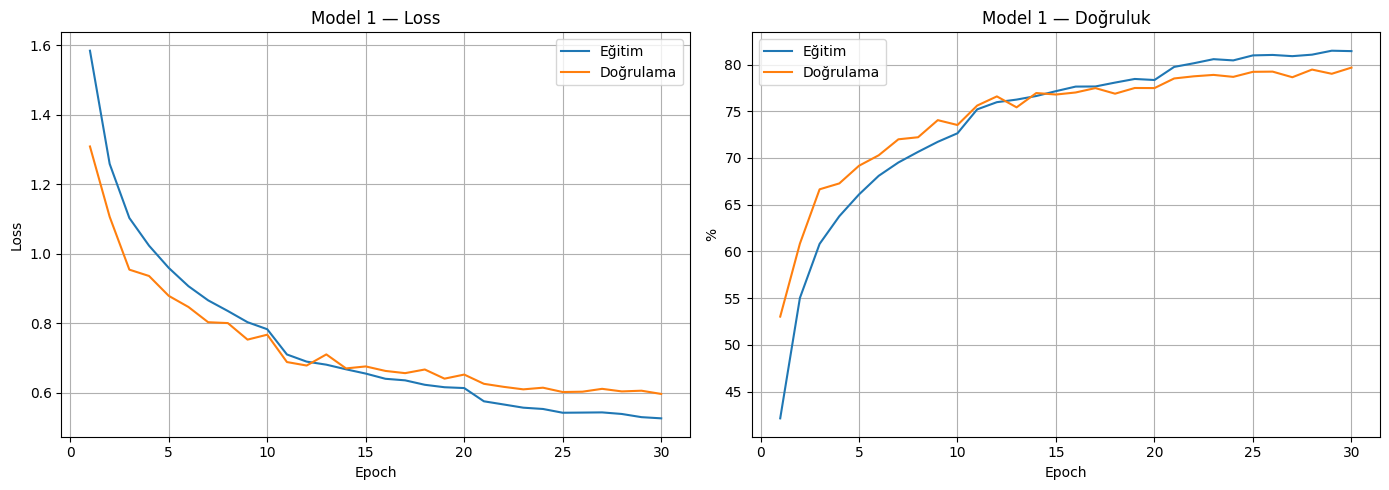

In [9]:
# ── Loss & Doğruluk Grafikleri ────────────────────────────────────────────────
ep_r = range(1, EPOCHS+1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(ep_r, hist['tl'], label='Eğitim');    a1.plot(ep_r, hist['vl'], label='Doğrulama')
a1.set(title='Model 1 — Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid()
a2.plot(ep_r, hist['ta'], label='Eğitim');    a2.plot(ep_r, hist['va'], label='Doğrulama')
a2.set(title='Model 1 — Doğruluk', xlabel='Epoch', ylabel='%'); a2.legend(); a2.grid()
plt.tight_layout(); plt.savefig('model1_curves.png', dpi=150); plt.show()

=== Sınıflandırma Raporu — Model 1 ===
              precision    recall  f1-score   support

       plane       0.79      0.84      0.81      1000
         car       0.90      0.88      0.89      1000
        bird       0.71      0.72      0.72      1000
         cat       0.65      0.58      0.61      1000
        deer       0.79      0.78      0.78      1000
         dog       0.75      0.67      0.70      1000
        frog       0.81      0.87      0.84      1000
       horse       0.80      0.88      0.84      1000
        ship       0.87      0.89      0.88      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.79      0.80      0.79     10000
weighted avg       0.79      0.80      0.79     10000



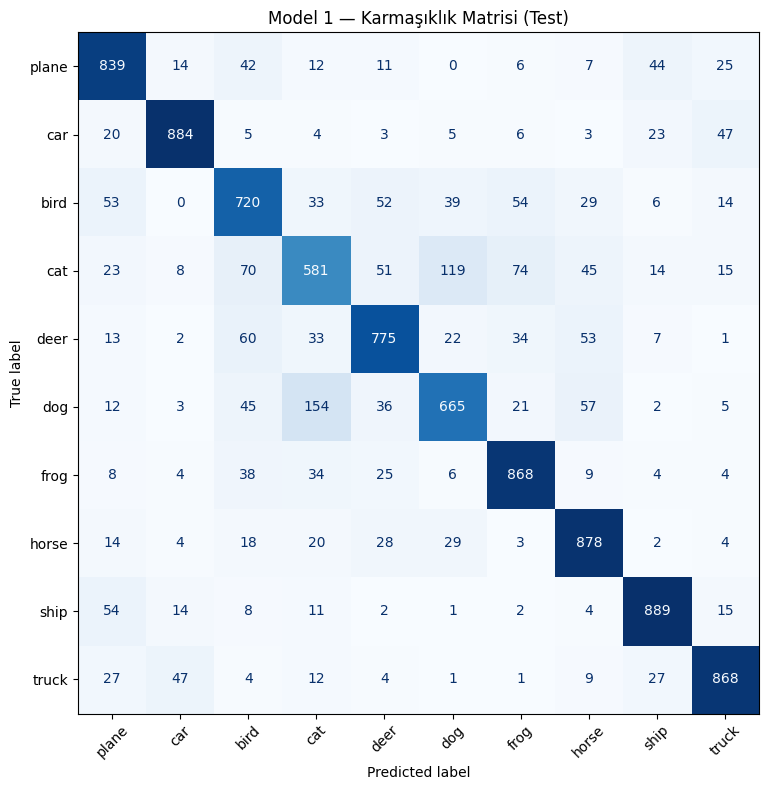


Model 1 Nihai Test Doğruluğu: 79.67%


In [10]:
# ── Test Değerlendirmesi & Karmaşıklık Matrisi ────────────────────────────────
model1.load_state_dict(torch.load('model1_best.pth', map_location=DEVICE))
model1.eval()
preds, labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        preds.extend(model1(X.to(DEVICE)).argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print('=== Sınıflandırma Raporu — Model 1 ===')
print(classification_report(labels, preds, target_names=CLASSES))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Model 1 — Karmaşıklık Matrisi (Test)')
plt.tight_layout(); plt.savefig('model1_confusion.png', dpi=150); plt.show()
print(f'\nModel 1 Nihai Test Doğruluğu: {best_acc:.2f}%')